In [44]:
from keras.datasets import mnist
from keras.utils import to_categorical
from keras import layers,models,regularizers
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

In [45]:
(train_x,train_y),(test_x,test_y) = mnist.load_data()
print(f"train_x shape : {train_x.shape}")
print(f"train_y shape : {train_y.shape}")
print(f"test_x shape : {test_x.shape}")
print(f"test_y shape : {test_y.shape}")

train_x shape : (60000, 28, 28)
train_y shape : (60000,)
test_x shape : (10000, 28, 28)
test_y shape : (10000,)


In [46]:
dataSize = -1
if train_x.ndim > 2 :
    dataSize = train_x.shape[-1]*train_x.shape[-2]
else :
    dataSize = train_x.shape[-1]
print(f"dataSize : {dataSize}")

dataSize : 784


In [47]:
train_x = train_x.reshape((train_x.shape[0],dataSize)).astype('float') / 255
test_x = test_x.reshape((test_x.shape[0] , dataSize)).astype('float') / 255

train_y = to_categorical(train_y)
test_y = to_categorical(test_y)

In [48]:
validation_x = train_x[40000:]
validation_y = train_y[40000:]

train_x = train_x[:40000]
train_y = train_y[:40000]

In [49]:
def buildModel(neuronNum) :
    model = models.Sequential([
        layers.Dense(neuronNum , activation='relu' , input_shape=(dataSize,)) , 
        layers.Dense(neuronNum , activation='relu') , 
        layers.Dense(10 , activation='softmax')
    ])
    model.compile(optimizer='rmsprop',loss='categorical_crossentropy',metrics=['accuracy'])
    return model

In [86]:
model_1 = buildModel(512).fit(train_x,train_y,epochs=4,batch_size=256,validation_data=(validation_x,validation_y))

Epoch 1/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8917 - loss: 0.3576 - val_accuracy: 0.8645 - val_loss: 0.4179
Epoch 2/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9617 - loss: 0.1258 - val_accuracy: 0.9643 - val_loss: 0.1180
Epoch 3/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9761 - loss: 0.0794 - val_accuracy: 0.9572 - val_loss: 0.1409
Epoch 4/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9841 - loss: 0.0523 - val_accuracy: 0.9727 - val_loss: 0.0988


In [87]:
def plotLossAcc (history) :
    history = history.history
    loss = history['loss']
    val_loss = history['val_loss']
    acc = history['accuracy']
    val_acc = history['val_accuracy']
    epochs = range(1,len(loss)+1)
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(epochs,loss,'b',label='Loss')
    plt.plot(epochs,val_loss,'r',label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1,2,2)
    plt.plot(epochs,acc,'b',label='Accuracy')
    plt.plot(epochs,val_acc,'r',label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.show()

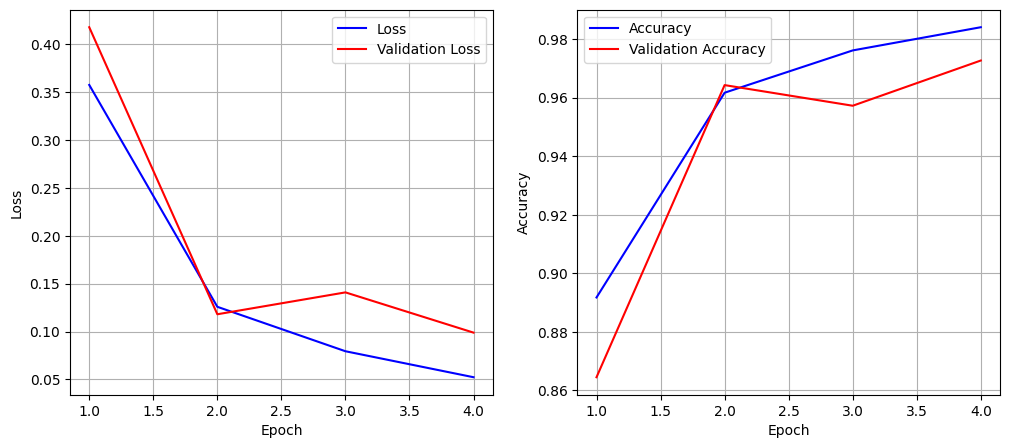

BestLoss : 0.09884384 at Epoch : 3
BestAcc : 0.97270000 at Epoch : 3


In [91]:
plotLossAcc(model_1)
bestLoss = min(model_1.history['val_loss'])
bestLossEpoch = model_1.history['val_loss'].index(bestLoss)
print(f"BestLoss : {bestLoss:.8f} at Epoch : {bestLossEpoch}")
bestAcc = model_1.history['val_accuracy'][bestLossEpoch]
print(f"BestAcc : {bestAcc:.8f} at Epoch : {bestLossEpoch}")

In [100]:
loss_ori , acc_ori = model_1.model.evaluate(test_x,test_y)
print(f"Loss : {loss_ori} , Acc : {acc_ori}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 603us/step - accuracy: 0.9763 - loss: 0.0813
Loss : 0.08126150071620941 , Acc : 0.9763000011444092


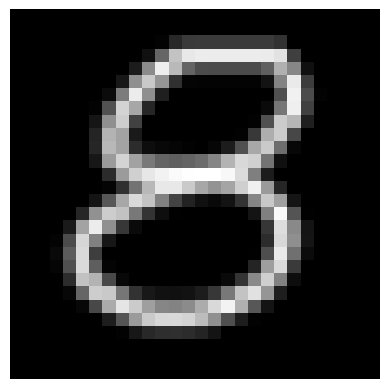

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
ผลการทำนาย: เลข 4
ความมั่นใจ: 100.00%


In [99]:
filename = 'test8.png'
img = load_img(filename,color_mode='grayscale',target_size=(28,28))

img_array = img_to_array(img)
img_array = 255.0 - img_array

img_array = img_array.reshape((1,28*28)).astype('float')/255.0

plt.imshow(img_array.reshape(28,28) , cmap='gray')
plt.axis('off')
plt.show()

prediction = model_1.model.predict(img_array)
predicted_digit = np.argmax(prediction)

print(f"ผลการทำนาย: เลข {predicted_digit}")
print(f"ความมั่นใจ: {prediction[0][predicted_digit] * 100:.2f}%")

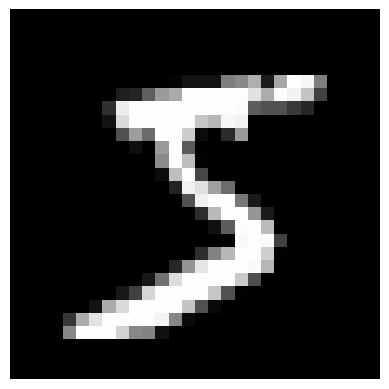

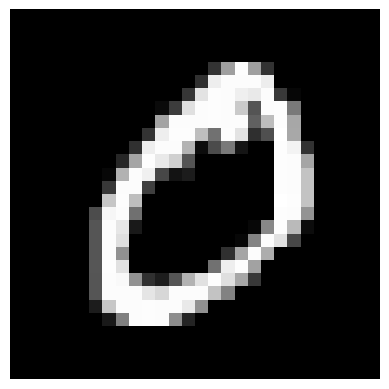

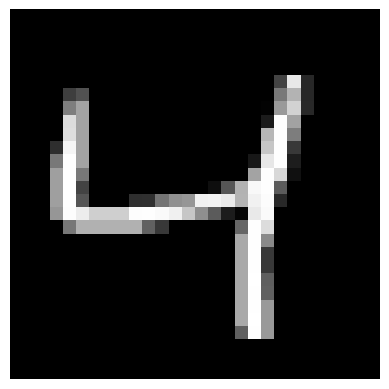

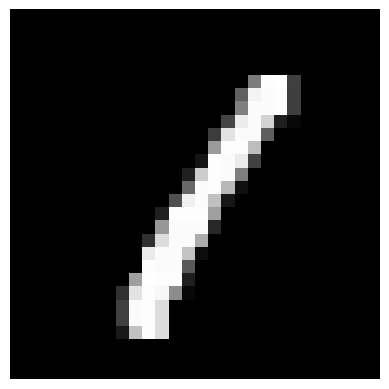

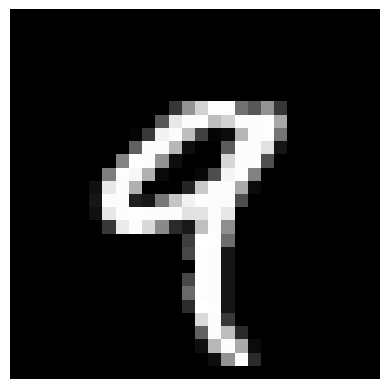

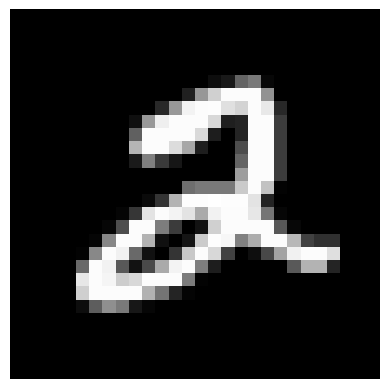

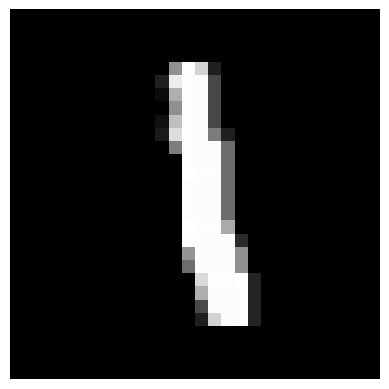

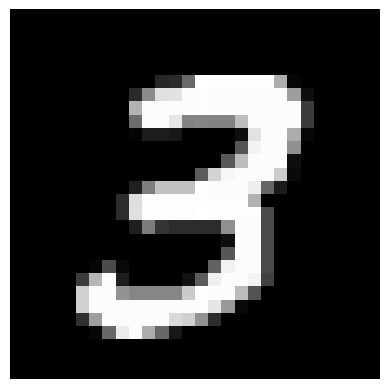

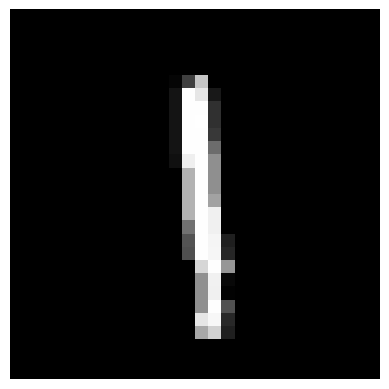

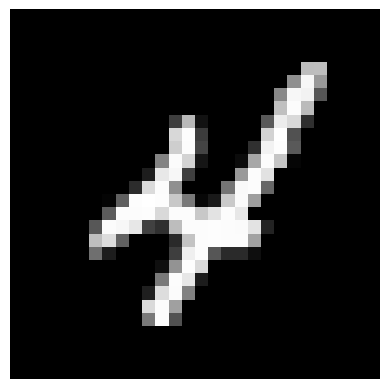

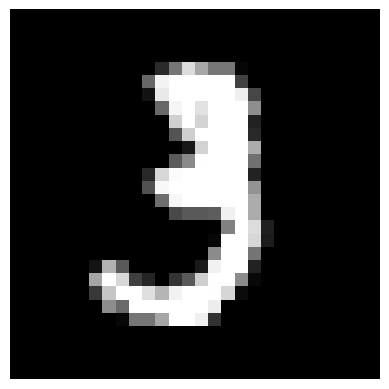

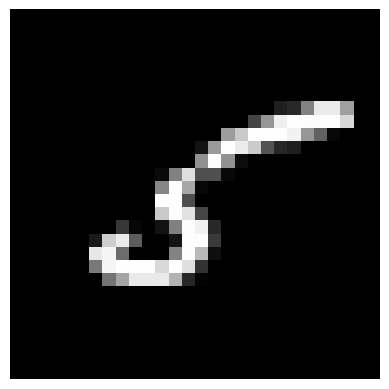

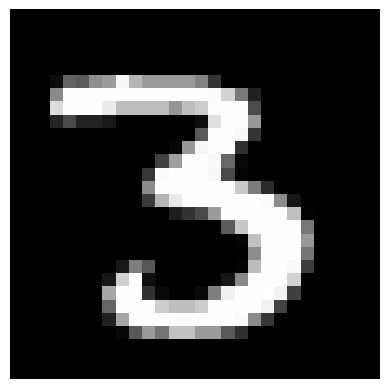

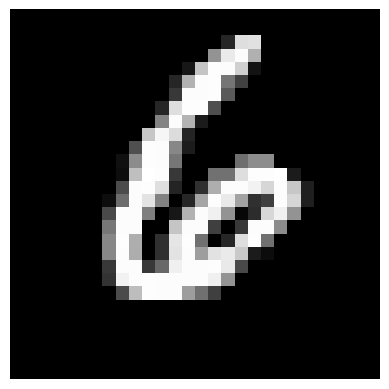

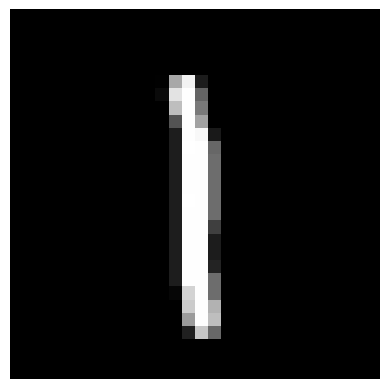

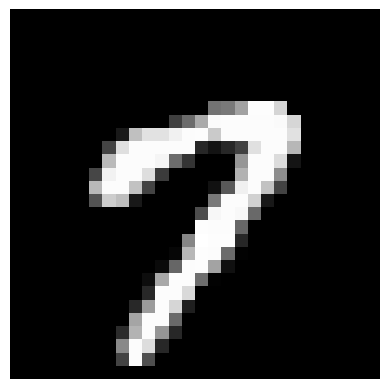

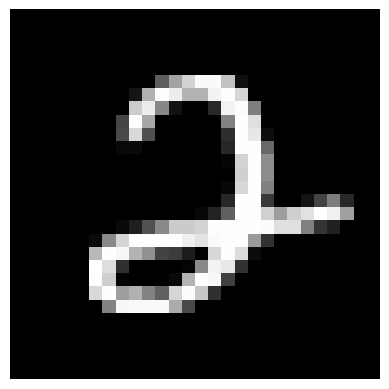

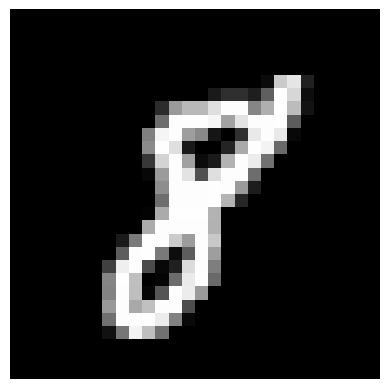

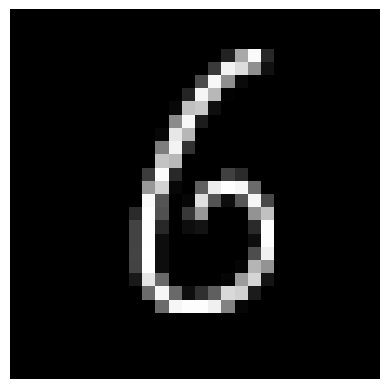

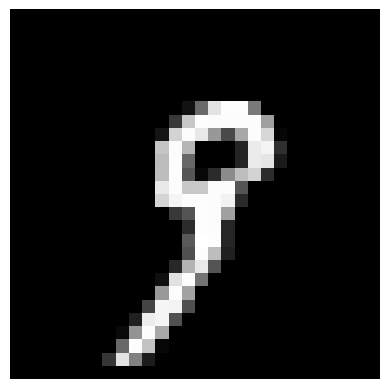

In [104]:
for i in range(20) :
    plt.imshow(train_x[i].reshape(28,28) , cmap='gray')
    plt.axis('off')
    plt.show()